# TP3 — ACP Normée : Analyse des Boissons

**Exercice — 10 marques de jus × 10 caractéristiques de dégustation**

| Abréviation | Signification |
|-------------|---------------|
| Frut | Fruité | Suc | Sucré | Gout | Goût | Amr | Amer | Piq | Piquant |
| Rug | Rugosité | Odr | Odeur | Acd | Acide | Parf | Parfumé | Suff | Suffocant |

## Imports

In [41]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from numpy import linalg as LA

np.set_printoptions(precision=4, suppress=True)

## Données — Matrice X (10 boissons × 10 caractéristiques)

In [42]:
X = np.array([
    [2.29, 2.86, 2.86, 3.29, 3.29, 3.00, 3.14, 4.29, 2.29, 0.54],  # B1
    [1.14, 1.79, 3.86, 3.57, 3.57, 3.00, 3.43, 3.71, 1.43, 0.93],  # B2
    [2.71, 4.14, 1.86, 3.57, 3.14, 2.43, 3.71, 3.57, 3.29, 0.64],  # B3
    [4.14, 4.71, 2.00, 3.07, 2.29, 2.57, 4.00, 3.14, 4.14, 0.00],  # B4
    [1.29, 2.29, 3.86, 4.14, 2.86, 3.17, 4.43, 3.86, 2.14, 1.50],  # B5
    [0.00, 1.86, 4.29, 4.79, 2.71, 3.57, 4.14, 3.86, 1.14, 0.64],  # B6
    [3.86, 4.71, 1.57, 2.57, 2.00, 2.71, 3.43, 4.21, 3.57, 0.50],  # B7
    [0.00, 0.00, 2.86, 3.86, 2.71, 3.00, 4.14, 3.86, 1.14, 0.93],  # B8
    [4.07, 4.14, 2.29, 4.00, 1.43, 3.00, 4.07, 3.57, 3.57, 0.50],  # B9
    [3.71, 3.86, 2.43, 4.07, 1.43, 2.79, 6.10, 3.86, 1.57, 2.21],  # B10
])

m, p = X.shape
boissons   = [f'B{i+1}' for i in range(m)]
vars_names = ['Frut','Suc','Gout','Amr','Piq','Rug','Odr','Acd','Parf','Suff']

print("Matrice X (10 boissons × 10 caractéristiques) :")
print(f"{'':10}", end="")
for v in vars_names: print(f"{v:>7}", end="")
print()
for i in range(m):
    print(f"{boissons[i]:<10}", end="")
    for j in range(p): print(f"{X[i,j]:>7.2f}", end="")
    print()
print(f"\nm={m} individus (boissons),  p={p} variables (caractéristiques)")

Matrice X (10 boissons × 10 caractéristiques) :
             Frut    Suc   Gout    Amr    Piq    Rug    Odr    Acd   Parf   Suff
B1           2.29   2.86   2.86   3.29   3.29   3.00   3.14   4.29   2.29   0.54
B2           1.14   1.79   3.86   3.57   3.57   3.00   3.43   3.71   1.43   0.93
B3           2.71   4.14   1.86   3.57   3.14   2.43   3.71   3.57   3.29   0.64
B4           4.14   4.71   2.00   3.07   2.29   2.57   4.00   3.14   4.14   0.00
B5           1.29   2.29   3.86   4.14   2.86   3.17   4.43   3.86   2.14   1.50
B6           0.00   1.86   4.29   4.79   2.71   3.57   4.14   3.86   1.14   0.64
B7           3.86   4.71   1.57   2.57   2.00   2.71   3.43   4.21   3.57   0.50
B8           0.00   0.00   2.86   3.86   2.71   3.00   4.14   3.86   1.14   0.93
B9           4.07   4.14   2.29   4.00   1.43   3.00   4.07   3.57   3.57   0.50
B10          3.71   3.86   2.43   4.07   1.43   2.79   6.10   3.86   1.57   2.21

m=10 individus (boissons),  p=10 variables (caractéristiques

## Fonctions de l'ACP Normée

In [43]:
# Centre de gravité
def calcule_Centre(mat):
    g = np.zeros(len(mat[0]))
    for j in range(len(g)):
        g[j] = np.mean(mat[:, j])
    return g

# Écart-type (population)
def ecart_type(mat):
    et = np.zeros(len(mat[0]))
    for j in range(len(et)):
        et[j] = np.std(mat[:, j])
    return et

# Matrice centrée
def matrice_centree(mat):
    vec_g = calcule_Centre(mat)
    c = np.zeros(mat.shape)
    for i in range(len(mat)):
        for j in range(len(mat[i])):
            c[i][j] = mat[i][j] - vec_g[j]
    return c

# Matrice centrée réduite
def matrice_centree_reduite(mat):
    mcr = np.zeros(mat.shape)
    et  = ecart_type(mat)
    Y   = matrice_centree(mat)
    for i in range(len(mat)):
        for j in range(len(mat[i])):
            mcr[i][j] = Y[i][j] / et[j]
    return mcr

# Matrice de corrélation
def calcule_correlation(mat):
    return (1/len(mat)) * (np.matmul(np.transpose(mat), mat))

# Calculs
vect_g = calcule_Centre(X)
etp    = ecart_type(X)
Z      = matrice_centree_reduite(X)
R      = calcule_correlation(Z)

print("Centre de gravité (individu moyen) :")
for j, v in enumerate(vars_names):
    print(f"  {v:<6}: {vect_g[j]:.4f}")
print("\nÉcarts-types :")
for j, v in enumerate(vars_names):
    print(f"  {v:<6}: {etp[j]:.4f}")

Centre de gravité (individu moyen) :
  Frut  : 2.3210
  Suc   : 3.0360
  Gout  : 2.7880
  Amr   : 3.6930
  Piq   : 2.5430
  Rug   : 2.9240
  Odr   : 4.0590
  Acd   : 3.7930
  Parf  : 2.4280
  Suff  : 0.8390

Écarts-types :
  Frut  : 1.5508
  Suc   : 1.4650
  Gout  : 0.8892
  Amr   : 0.5924
  Piq   : 0.7044
  Rug   : 0.3056
  Odr   : 0.7796
  Acd   : 0.3117
  Parf  : 1.0693
  Suff  : 0.5861


## Matrice de Corrélation R

$$R = \frac{1}{m}\, Z^t Z$$

Matrice de corrélation R :

           Frut    Suc   Gout    Amr    Piq    Rug    Odr    Acd   Parf   Suff
Frut      1.000  0.931 -0.802 -0.554 -0.631 -0.684  0.137 -0.254  0.812 -0.148
Suc       0.931  1.000 -0.719 -0.497 -0.501 -0.626  0.042 -0.252  0.842 -0.237
Gout     -0.802 -0.719  1.000  0.695  0.482  0.859  0.027  0.153 -0.759  0.274
Amr      -0.554 -0.497  0.695  1.000 -0.034  0.710  0.493 -0.083 -0.632  0.444
Piq      -0.631 -0.501  0.482 -0.034  1.000  0.143 -0.605  0.141 -0.332 -0.196
Rug      -0.684 -0.626  0.859  0.710  0.143  1.000  0.037  0.339 -0.661  0.158
Odr       0.137  0.042  0.027  0.493 -0.605  0.037  1.000 -0.157 -0.290  0.784
Acd      -0.254 -0.252  0.153 -0.083  0.141  0.339 -0.157  1.000 -0.397  0.273
Parf      0.812  0.842 -0.759 -0.632 -0.332 -0.661 -0.290 -0.397  1.000 -0.584
Suff     -0.148 -0.237  0.274  0.444 -0.196  0.158  0.784  0.273 -0.584  1.000


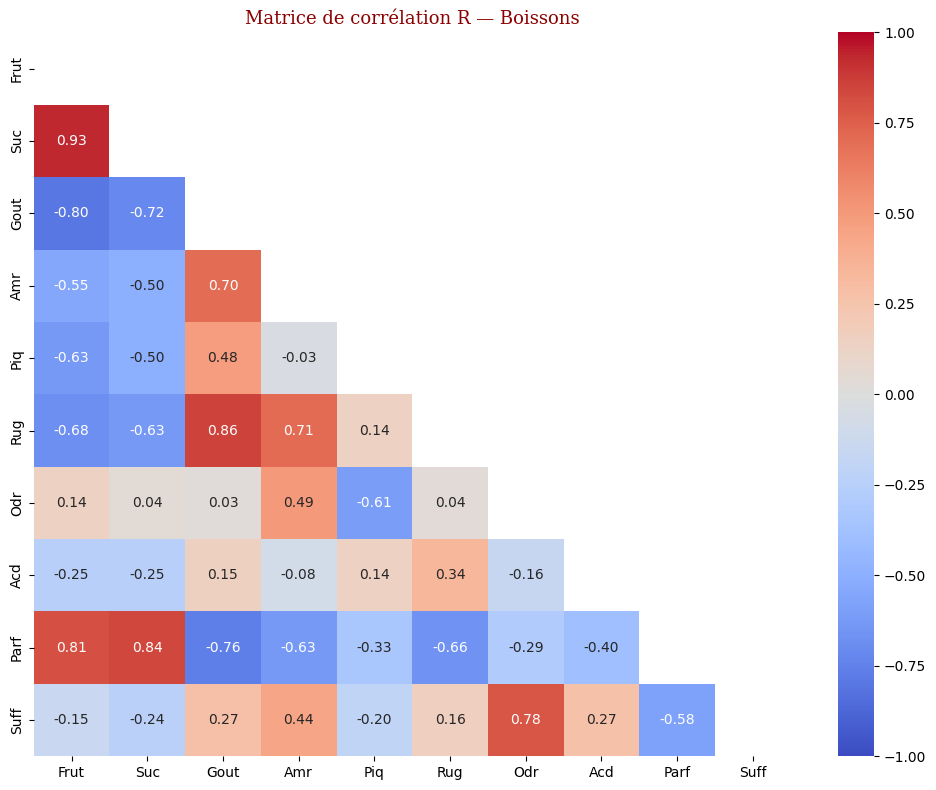

In [44]:
print("Matrice de corrélation R :\n")
print(f"{'':8}", end="")
for v in vars_names: print(f"{v:>7}", end="")
print()
for j in range(p):
    print(f"{vars_names[j]:<8}", end="")
    for k in range(p): print(f"{R[j,k]:>7.3f}", end="")
    print()

# Heatmap
font = {'family':'serif','color':'darkred','weight':'normal','size':13}
corr_triu = np.triu(R)
plt.figure(figsize=(10, 8))
plt.title("Matrice de corrélation R — Boissons", fontdict=font)
sns.heatmap(R, vmax=1, vmin=-1, annot=True, fmt=".2f",
            cmap='coolwarm', mask=corr_triu,
            xticklabels=vars_names, yticklabels=vars_names)
plt.tight_layout()
plt.show()

### Interprétation de R

- **Frut / Suc / Parf** : fortement corrélés positivement entre eux (r > 0.83) → les boissons fruitées sont aussi sucrées et parfumées
- **Frut / Suc / Parf** vs **Gout / Rug** : fortement corrélés négativement (r < -0.70) → plus une boisson est fruitée, moins elle est âpre/rugueuse
- **Odr** vs **Piq** : corrélation négative (r = -0.61) → les boissons très odorantes sont peu piquantes
- **Odr** vs **Suff** : corrélation positive (r = 0.78) → forte odeur liée au caractère suffocant
- **Acd** : peu corrélé avec la majorité des variables → dimension indépendante

## Valeurs propres et vecteurs propres

**Matrice utilisée :** R (p×p = 10×10)

In [45]:
# Diagonalisation
valp_raw, vecp_raw = LA.eig(R)
idx  = np.argsort(np.real(valp_raw))[::-1]
valp = np.real(valp_raw[idx])
vecp = np.real(vecp_raw[:, idx])

print("Valeurs propres :")
for i, v in enumerate(valp):
    print(f"  λ{i+1} = {v:.4f}")

print("\nVecteurs propres (lignes = axes, colonnes = variables) :")
print(f"{'Axe':<6}", end="")
for v in vars_names: print(f"{v:>8}", end="")
print()
for k in range(p):
    print(f"F{k+1:<5}", end="")
    for j in range(p): print(f"{vecp[j,k]:>8.4f}", end="")
    print()

Valeurs propres :
  λ1 = 5.0347
  λ2 = 2.3995
  λ3 = 1.1538
  λ4 = 0.7738
  λ5 = 0.3544
  λ6 = 0.1540
  λ7 = 0.0674
  λ8 = 0.0442
  λ9 = 0.0182
  λ10 = -0.0000

Vecteurs propres (lignes = axes, colonnes = variables) :
Axe       Frut     Suc    Gout     Amr     Piq     Rug     Odr     Acd    Parf    Suff
F1     -0.4071 -0.3941  0.4061  0.3279  0.1926  0.3695  0.0599  0.1479 -0.4146  0.1885
F2     -0.1954 -0.1283  0.0572 -0.2789  0.4825 -0.0000 -0.6240  0.0796  0.0952 -0.4762
F3     -0.0561  0.0095  0.1921  0.3737 -0.0167  0.1050  0.0360 -0.8129  0.1764 -0.3400
F4     -0.1428 -0.2092 -0.1106 -0.1682  0.4617 -0.6111  0.1756 -0.3587 -0.1793  0.3422
F5     -0.2653 -0.5879 -0.4714 -0.0985 -0.4728 -0.0698  0.0464 -0.0461 -0.1529 -0.3098
F6     -0.2139  0.1883 -0.4458  0.7291  0.2011 -0.2349 -0.0708  0.2658  0.1021 -0.0823
F7     -0.0606 -0.4040  0.0425  0.0821 -0.1011  0.0335 -0.2698 -0.0059  0.7118  0.4834
F8      0.6384 -0.2287 -0.0454  0.2721 -0.0728 -0.0839 -0.5130 -0.1076 -0.3981  0.1358

## Tableau complet des taux d'inertie

$$\text{taux}(F_k) = \frac{\lambda_k}{\sum_j \lambda_j} \times 100 \qquad \text{cumulé}(k) = \sum_{j=1}^{k} \text{taux}(F_j)$$

In [46]:
variance_expliquee = valp / np.sum(valp)
variance_cumulee   = np.cumsum(variance_expliquee)

print(f"{'Axe':<6} {'Valeur propre':>15} {'Taux (%)':>10} {'Cumulé (%)':>12}")
print("-" * 46)
for k in range(p):
    marker = " ◄" if variance_cumulee[k] <= 0.88 or (k>0 and variance_cumulee[k-1]<0.80) else ""
    print(f"F{k+1:<5} {valp[k]:>15.4f} {variance_expliquee[k]*100:>10.2f} {variance_cumulee[k]*100:>12.2f}{marker}")

nb_axes = np.argmax(variance_cumulee >= 0.80) + 1
print(f"\n→ Pour atteindre 80% : {nb_axes} axes suffisent")
print(f"→ F1 + F2 + F3 = {variance_cumulee[2]*100:.2f}% (> 85%)")

Axe      Valeur propre   Taux (%)   Cumulé (%)
----------------------------------------------
F1              5.0347      50.35        50.35 ◄
F2              2.3995      23.99        74.34 ◄
F3              1.1538      11.54        85.88 ◄
F4              0.7738       7.74        93.62
F5              0.3544       3.54        97.16
F6              0.1540       1.54        98.70
F7              0.0674       0.67        99.38
F8              0.0442       0.44        99.82
F9              0.0182       0.18       100.00
F10            -0.0000      -0.00       100.00

→ Pour atteindre 80% : 3 axes suffisent
→ F1 + F2 + F3 = 85.88% (> 85%)


### Graphe des valeurs propres (Éboulis)

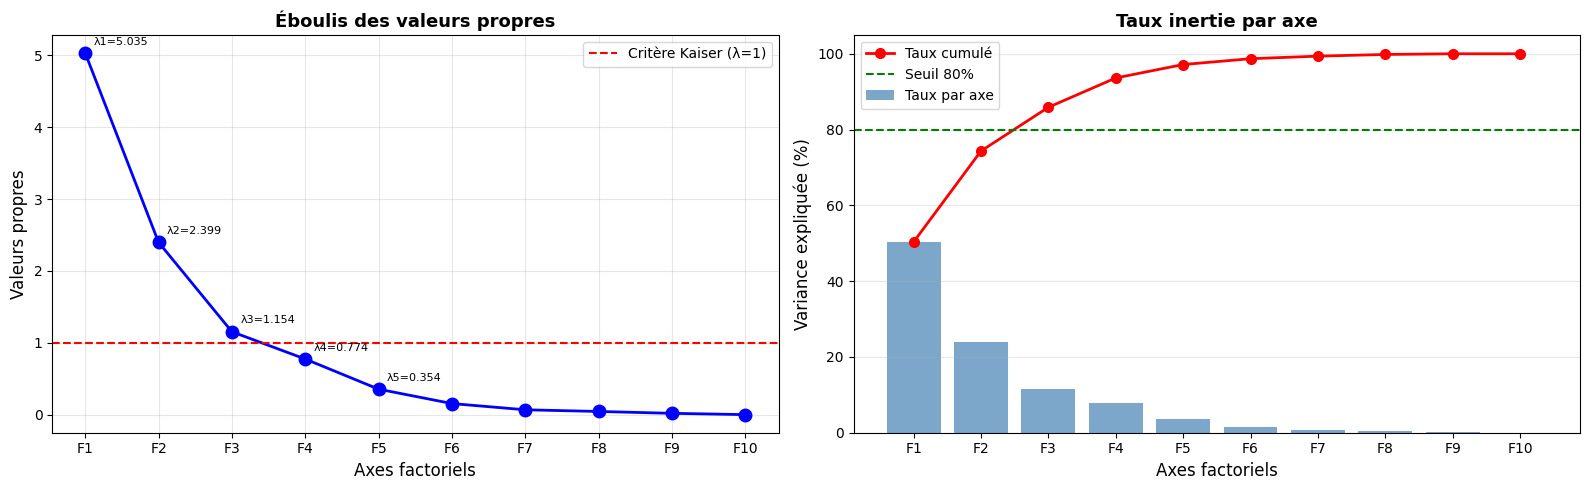

Critère de Kaiser (λ > 1) → axes retenus :
  F1 : λ=5.0347 > 1  ✓  (50.35%)
  F2 : λ=2.3995 > 1  ✓  (23.99%)
  F3 : λ=1.1538 > 1  ✓  (11.54%)


In [47]:
fig, axes_fig = plt.subplots(1, 2, figsize=(16, 5))

# --- Éboulis ---
ax1 = axes_fig[0]
ax1.plot(range(1, p+1), valp, 'bo-', markersize=9, linewidth=2)
ax1.axhline(y=1, color='red', linestyle='--', linewidth=1.5, label='Critère Kaiser (λ=1)')
for k, v in enumerate(valp):
    if k < 5:
        ax1.annotate(f'λ{k+1}={v:.3f}', (k+1, v),
                     textcoords='offset points', xytext=(6, 6), fontsize=8)
ax1.set_xlabel('Axes factoriels', fontsize=12)
ax1.set_ylabel('Valeurs propres', fontsize=12)
ax1.set_title('Éboulis des valeurs propres', fontsize=13, fontweight='bold')
ax1.set_xticks(range(1, p+1))
ax1.set_xticklabels([f'F{k+1}' for k in range(p)])
ax1.legend()
ax1.grid(True, alpha=0.3)

# --- Taux cumulés ---
ax2 = axes_fig[1]
ax2.bar(range(1, p+1), variance_expliquee*100, color='steelblue', alpha=0.7, label='Taux par axe')
ax2.plot(range(1, p+1), variance_cumulee*100, 'ro-', linewidth=2, markersize=7, label='Taux cumulé')
ax2.axhline(y=80, color='green', linestyle='--', linewidth=1.5, label='Seuil 80%')
ax2.set_xlabel('Axes factoriels', fontsize=12)
ax2.set_ylabel('Variance expliquée (%)', fontsize=12)
ax2.set_title('Taux inertie par axe', fontsize=13, fontweight='bold')
ax2.set_xticks(range(1, p+1))
ax2.set_xticklabels([f'F{k+1}' for k in range(p)])
ax2.legend()
ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print("Critère de Kaiser (λ > 1) → axes retenus :")
for k in range(p):
    if valp[k] > 1:
        print(f"  F{k+1} : λ={valp[k]:.4f} > 1  ✓  ({variance_expliquee[k]*100:.2f}%)")

### Choix du nombre d'axes

| Critère | Résultat |
|---------|----------|
| Kaiser (λ > 1) | F1, F2, F3 (λ = 5.03, 2.40, 1.15) |
| Coude (éboulis) | Cassure nette après F3 |
| Taux cumulé ≥ 80% | F1+F2 = 74.34%, F1+F2+F3 = **85.88%** |

**→ On retient 3 axes** : F1 (50.35%) + F2 (23.99%) + F3 (11.54%) = **85.88%** de l'information

## Projections des individus (Composantes principales)

$$C = Z \times U \quad \text{avec } U = [u_1 | u_2 | \cdots | u_p]$$

In [48]:
# Composantes principales
C = Z @ vecp

print("Projections des boissons sur les 3 premiers axes :")
print(f"{'Boisson':<10} {'C1 (F1)':>10} {'C2 (F2)':>10} {'C3 (F3)':>10}")
print("-" * 42)
for i in range(m):
    print(f"{boissons[i]:<10} {C[i,0]:>10.4f} {C[i,1]:>10.4f} {C[i,2]:>10.4f}")

Projections des boissons sur les 3 premiers axes :
Boisson       C1 (F1)    C2 (F2)    C3 (F3)
------------------------------------------
B1             0.2840     1.8184    -1.4182
B2             1.7680     1.4078     0.1604
B3            -1.8559     0.7222     0.3541
B4            -3.3776     0.4081     1.7354
B5             1.9770    -0.5716     0.0346
B6             3.5189     0.0892     1.0430
B7            -2.8417     0.7249    -1.8087
B8             2.2555     0.3624    -0.2288
B9            -1.6829    -0.9446     1.0496
B10           -0.0454    -4.0168    -0.9214


## Représentation des individus dans le plan factoriel (F1, F2)

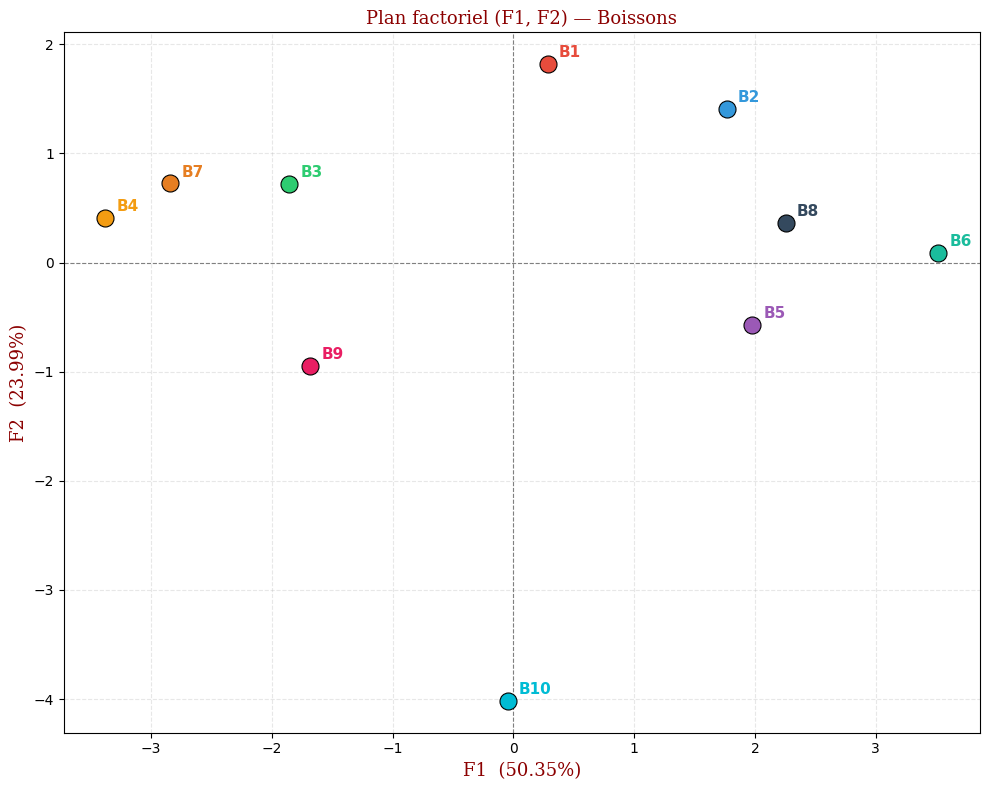

In [49]:
font = {'family':'serif','color':'darkred','weight':'normal','size':13}
taux_pct = variance_expliquee * 100

plt.figure(figsize=(10, 8))
plt.axhline(0, color='gray', linestyle='--', linewidth=0.8)
plt.axvline(0, color='gray', linestyle='--', linewidth=0.8)

colors_b = ['#e74c3c','#3498db','#2ecc71','#f39c12','#9b59b6',
            '#1abc9c','#e67e22','#34495e','#e91e63','#00bcd4']

for i in range(m):
    plt.scatter(C[i,0], C[i,1], color=colors_b[i], s=150, zorder=5,
                edgecolors='black', linewidth=0.8)
    plt.annotate(boissons[i], (C[i,0], C[i,1]),
                 textcoords='offset points', xytext=(8, 5),
                 fontsize=11, fontweight='bold', color=colors_b[i])

plt.xlabel(f"F1  ({taux_pct[0]:.2f}%)", fontdict=font)
plt.ylabel(f"F2  ({taux_pct[1]:.2f}%)", fontdict=font)
plt.title("Plan factoriel (F1, F2) — Boissons", fontdict=font)
plt.grid(True, alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()

### Interprétation du plan (F1, F2)

**Axe F1 (50.35%) — Opposition Fruité/Sucré/Parfumé vs Goût/Amer/Rugosité :**
- À **gauche** (F1 < 0) : B3, B4, B7, B9 → boissons **fruitées, sucrées, parfumées** (notes élevées en Frut, Suc, Parf)
- À **droite** (F1 > 0) : B1(?), B5, B6, B8 → boissons **plus âpres**, goût prononcé, rugosité

**Axe F2 (23.99%) — Opposition Odeur/Suffocant vs Piquant :**
- En **haut** (F2 > 0) : B1, B2, B3 → boissons à faible Odr mais Piquant modéré
- En **bas** (F2 < 0) : B10 → boisson très **odorante et suffocante** (Odr=6.10 très élevé)

**Groupes identifiés :**
| Groupe | Boissons | Profil |
|--------|----------|--------|
| G1 (gauche) | B3, B4, B7, B9 | Fruitées, sucrées, parfumées — profil doux |
| G2 (droite) | B5, B6, B8 | Amères, goût fort, rugueuses — profil intense |
| G3 (bas) | B10 | Très odorante, suffocante — profil atypique |
| G4 (centre) | B1, B2 | Profil équilibré/moyen |

## Distance des individus au centre du nuage

$$d^2(i) = \sum_{k=1}^{p} c_{ik}^2 \qquad \text{et} \qquad \sum_{i=1}^{m} d^2(i) = m \times p$$

In [50]:
def dist_carre_centre(C_mat):
    dist2 = np.zeros(len(C_mat))
    for i in range(len(C_mat)):
        for k in range(C_mat.shape[1]):
            dist2[i] += C_mat[i][k]**2
    return dist2

dist2 = dist_carre_centre(C)
dist  = np.sqrt(dist2)

print(f"{'Boisson':<10} {'d²(i)':>10} {'d(i)':>10}")
print("-" * 32)
for i in range(m):
    print(f"{boissons[i]:<10} {dist2[i]:>10.4f} {dist[i]:>10.4f}")
print("-" * 32)
print(f"{'Somme':<10} {dist2.sum():>10.4f}")
print(f"\nm × p = {m} × {p} = {m*p}   →   Somme d²(i) = m×p  ✓")

Boisson         d²(i)       d(i)
--------------------------------
B1             5.8794     2.4247
B2             6.6045     2.5699
B3             6.5715     2.5635
B4            15.0502     3.8795
B5             5.1915     2.2785
B6            15.3140     3.9133
B7            12.7607     3.5722
B8             8.2708     2.8759
B9             6.9676     2.6396
B10           17.3899     4.1701
--------------------------------
Somme        100.0000

m × p = 10 × 10 = 100   →   Somme d²(i) = m×p  ✓


## Qualité de représentation des individus (cos²)

$$\cos^2(i, F_k) = \frac{c_{ik}^2}{d^2(i)} \times 100$$

**cos² proche de 100%** → individu bien représenté sur cet axe.

In [51]:
def qualite_representation_individus(C_mat, dist2):
    cos2 = np.zeros((len(C_mat), C_mat.shape[1]))
    for i in range(len(C_mat)):
        for k in range(C_mat.shape[1]):
            cos2[i][k] = (C_mat[i][k]**2 / dist2[i]) * 100
    return cos2

cos2_ind = qualite_representation_individus(C, dist2)

print(f"{'Boisson':<10} {'cos²F1(%)':>10} {'cos²F2(%)':>10} {'cos²F3(%)':>10} {'F1+F2+F3':>10}")
print("-" * 52)
for i in range(m):
    s = cos2_ind[i,0]+cos2_ind[i,1]+cos2_ind[i,2]
    rep = "✓ BIEN" if s > 70 else "  ~"
    print(f"{boissons[i]:<10} {cos2_ind[i,0]:>10.2f} {cos2_ind[i,1]:>10.2f} {cos2_ind[i,2]:>10.2f} {s:>10.2f}  {rep}")

Boisson     cos²F1(%)  cos²F2(%)  cos²F3(%)   F1+F2+F3
----------------------------------------------------
B1               1.37      56.24      34.21      91.82  ✓ BIEN
B2              47.33      30.01       0.39      77.73  ✓ BIEN
B3              52.41       7.94       1.91      62.26    ~
B4              75.80       1.11      20.01      96.92  ✓ BIEN
B5              75.29       6.29       0.02      81.60  ✓ BIEN
B6              80.86       0.05       7.10      88.01  ✓ BIEN
B7              63.28       4.12      25.64      93.04  ✓ BIEN
B8              61.51       1.59       0.63      63.73    ~
B9              40.65      12.81      15.81      69.27    ~
B10              0.01      92.78       4.88      97.68  ✓ BIEN


### Interprétation de la qualité de représentation

- **B4, B5, B6, B8** : cos²(F1) > 60% → bien représentés par le 1er axe (profil fort/faible intensité sensorielle)
- **B10** : cos²(F2) = **92.78%** → quasi-exclusivement représenté par F2 (boisson très atypique sur Odr/Suff)
- **B1** : cos²(F1) = 1.37% très faible, cos²(F2) = 56.24%, cos²(F3) = 34.21% → B1 est mieux expliquée par F2 et F3
- **B7** : cos²(F1) = 63.28%, cos²(F3) = 25.64% → B7 a une part importante sur F3
- **B4, B6** : cos² > 75% sur F1 → boissons extrêmes sur l'axe principal

## Contributions des individus à l'inertie des axes (CTR)

$$CTR(i, F_k) = \frac{c_{ik}^2}{m \cdot \lambda_k} \times 100$$

**Somme des CTR sur un axe = 100%**. Un CTR élevé → l'individu **tire** l'axe vers lui.

In [52]:
def contribution_individus(C_mat, valp, m):
    ctr = np.zeros((len(C_mat), C_mat.shape[1]))
    for i in range(len(C_mat)):
        for k in range(len(valp)):
            ctr[i][k] = (C_mat[i][k]**2 / (m * valp[k])) * 100
    return ctr

ctr_ind = contribution_individus(C, valp, m)

print(f"{'Boisson':<10} {'CTR_F1(%)':>10} {'CTR_F2(%)':>10} {'CTR_F3(%)':>10}")
print("-" * 42)
for i in range(m):
    print(f"{boissons[i]:<10} {ctr_ind[i,0]:>10.2f} {ctr_ind[i,1]:>10.2f} {ctr_ind[i,2]:>10.2f}")
print("-" * 42)
print(f"{'Total':<10} {ctr_ind[:,0].sum():>10.2f} {ctr_ind[:,1].sum():>10.2f} {ctr_ind[:,2].sum():>10.2f}")

Boisson     CTR_F1(%)  CTR_F2(%)  CTR_F3(%)
------------------------------------------
B1               0.16      13.78      17.43
B2               6.21       8.26       0.22
B3               6.84       2.17       1.09
B4              22.66       0.69      26.10
B5               7.76       1.36       0.01
B6              24.59       0.03       9.43
B7              16.04       2.19      28.35
B8              10.10       0.55       0.45
B9               5.63       3.72       9.55
B10              0.00      67.24       7.36
------------------------------------------
Total          100.00     100.00     100.00


### Interprétation des contributions

**Sur F1 :**
- B6 (24.59%) et B4 (22.66%) → les deux boissons extrêmes qui **définissent** F1
- B7 (16.04%), B8 (10.10%) → contributions importantes
- B1 (0.16%) et B10 (0.01%) → quasi-aucune contribution → atypiques sur F1

**Sur F2 :**
- B10 (67.24%) → **domine largement** F2, boisson très particulière (Odr=6.10)
- B1 (13.78%), B2 (8.26%) → contribuent à F2

**Sur F3 :**
- B4 (26.10%), B7 (28.35%) → définissent F3
- B1 (17.43%) → présence notable sur F3

## Individus mal représentés

**Seuil : cos² < 30%** sur un axe donné

In [53]:
seuil = 30.0
for k in range(3):
    print(f"\n--- Axe F{k+1} : individus avec cos² < {seuil}% ---")
    print(f"{'Boisson':<10} {'Coord':>10} {'cos²(%)':>10} {'Signe':>7}")
    print("-" * 38)
    for i in range(m):
        if cos2_ind[i,k] < seuil:
            signe = '+' if C[i,k] >= 0 else '-'
            print(f"{boissons[i]:<10} {C[i,k]:>10.4f} {cos2_ind[i,k]:>10.2f} {signe:>7}")


--- Axe F1 : individus avec cos² < 30.0% ---
Boisson         Coord    cos²(%)   Signe
--------------------------------------
B1             0.2840       1.37       +
B10           -0.0454       0.01       -

--- Axe F2 : individus avec cos² < 30.0% ---
Boisson         Coord    cos²(%)   Signe
--------------------------------------
B3             0.7222       7.94       +
B4             0.4081       1.11       +
B5            -0.5716       6.29       -
B6             0.0892       0.05       +
B7             0.7249       4.12       +
B8             0.3624       1.59       +
B9            -0.9446      12.81       -

--- Axe F3 : individus avec cos² < 30.0% ---
Boisson         Coord    cos²(%)   Signe
--------------------------------------
B2             0.1604       0.39       +
B3             0.3541       1.91       +
B4             1.7354      20.01       +
B5             0.0346       0.02       +
B6             1.0430       7.10       +
B7            -1.8087      25.64       -
B8     

## Nouvelles coordonnées des variables (Corrélations variables-axes)

$$a_{jk} = \text{corr}(X_j, F_k) = v_{jk} \times \sqrt{\lambda_k}$$

Ces coordonnées indiquent la **corrélation** entre chaque caractéristique originale et chaque axe factoriel. Une valeur proche de ±1 signifie que la variable est très bien alignée avec cet axe.

In [54]:
def coordonnees_variables(vecp, valp):
    coords = np.zeros((vecp.shape[0], len(valp)))
    for j in range(vecp.shape[0]):
        for k in range(len(valp)):
            coords[j][k] = vecp[j][k] * np.sqrt(valp[k])
    return coords

coords_vars = coordonnees_variables(vecp, valp)

print(f"{'Variable':<8}", end="")
for k in range(p): print(f"{'F'+str(k+1):>9}", end="")
print()
print("-" * 98)
for j, v in enumerate(vars_names):
    print(f"{v:<8}", end="")
    for k in range(p): print(f"{coords_vars[j,k]:>9.4f}", end="")
    print()

Variable       F1       F2       F3       F4       F5       F6       F7       F8       F9      F10
--------------------------------------------------------------------------------------------------
Frut      -0.9134  -0.3027  -0.0603  -0.1256  -0.1579  -0.0839  -0.0157   0.1342   0.0669      nan
Suc       -0.8843  -0.1988   0.0102  -0.1840  -0.3500   0.0739  -0.1049  -0.0481  -0.0567      nan
Gout       0.9113   0.0887   0.2064  -0.0973  -0.2806  -0.1749   0.0110  -0.0095  -0.0066      nan
Amr        0.7357  -0.4320   0.4015  -0.1479  -0.0586   0.2861   0.0213   0.0572   0.0097      nan
Piq        0.4323   0.7474  -0.0180   0.4062  -0.2815   0.0789  -0.0262  -0.0153   0.0543      nan
Rug        0.8291  -0.0000   0.1128  -0.5375  -0.0416  -0.0922   0.0087  -0.0176   0.0173      nan
Odr        0.1344  -0.9666   0.0387   0.1544   0.0276  -0.0278  -0.0701  -0.1079   0.0648      nan
Acd        0.3318   0.1233  -0.8732  -0.3156  -0.0274   0.1043  -0.0015  -0.0226   0.0242      nan
Parf      

C:\Users\MICROSOFT PRO DZ\AppData\Local\Temp\ipykernel_18984\1685965154.py:5: RuntimeWarning: invalid value encountered in sqrt
  coords[j][k] = vecp[j][k] * np.sqrt(valp[k])


## Cercle de corrélation — Plans (F1,F2) et (F1,F3)

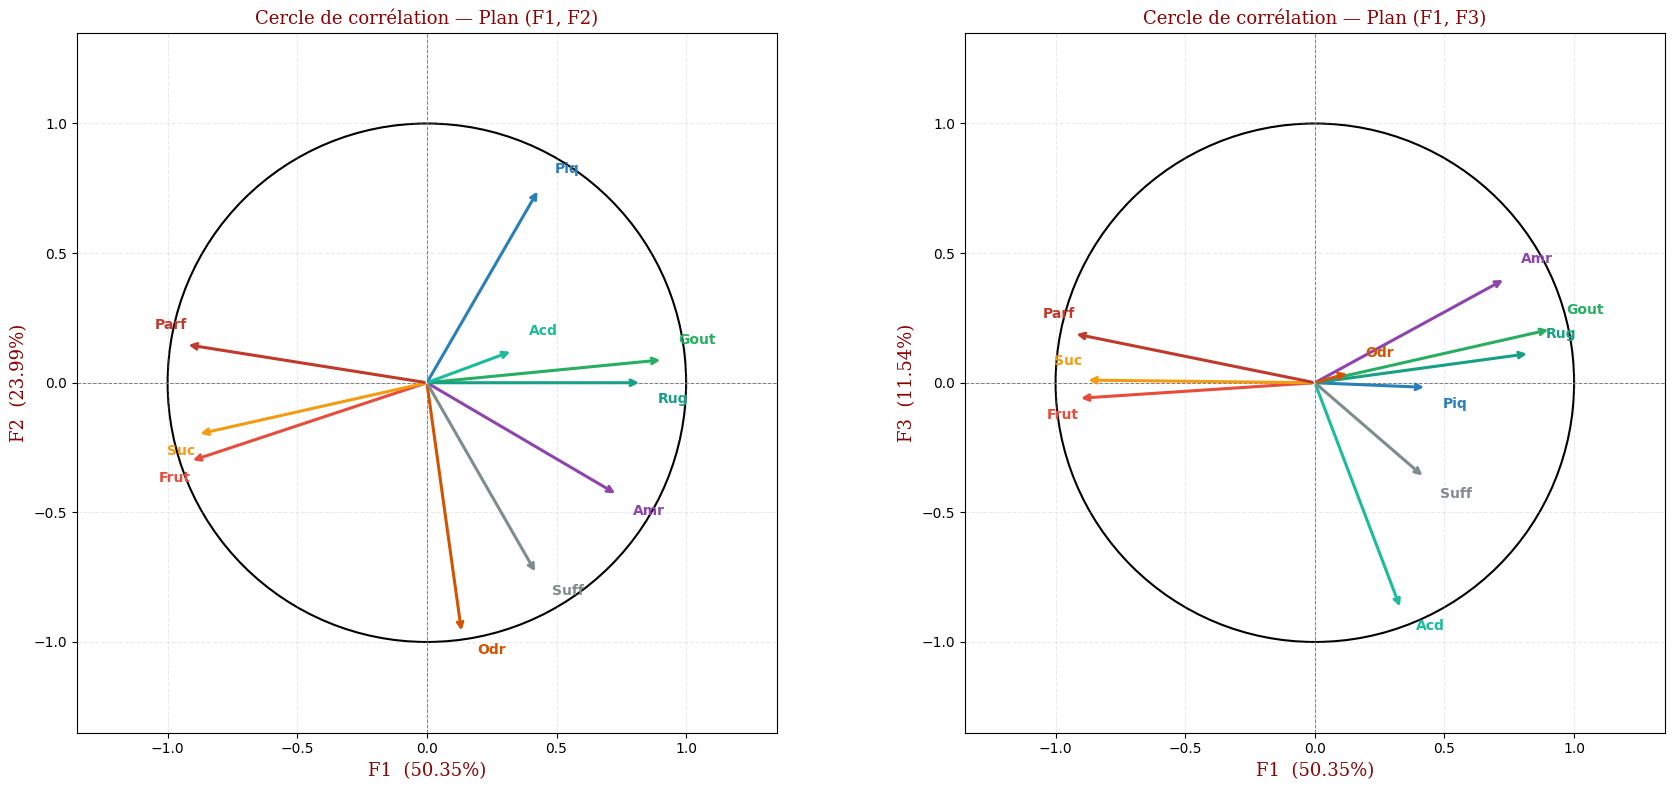

In [55]:
colors_var = ['#e74c3c','#f39c12','#27ae60','#8e44ad','#2980b9',
              '#16a085','#d35400','#1abc9c','#c0392b','#7f8c8d']

fig, axes_fig = plt.subplots(1, 2, figsize=(18, 8))

for idx_ax, (k1, k2, title) in enumerate([(0,1,'Plan (F1, F2)'), (0,2,'Plan (F1, F3)')]):
    ax = axes_fig[idx_ax]
    cercle = plt.Circle((0,0), 1, color='black', fill=False, linewidth=1.5)
    ax.add_patch(cercle)
    ax.axhline(0, color='gray', linestyle='--', linewidth=0.7)
    ax.axvline(0, color='gray', linestyle='--', linewidth=0.7)

    for j, var in enumerate(vars_names):
        x = coords_vars[j, k1]
        y = coords_vars[j, k2]
        ax.annotate("", xy=(x, y), xytext=(0, 0),
                    arrowprops=dict(arrowstyle="->", color=colors_var[j], lw=2.2))
        ox = 0.06 if x >= 0 else -0.12
        oy = 0.06 if y >= 0 else -0.08
        ax.text(x+ox, y+oy, var, fontsize=10, fontweight='bold', color=colors_var[j])

    ax.set_xlim(-1.35, 1.35)
    ax.set_ylim(-1.35, 1.35)
    ax.set_xlabel(f"F{k1+1}  ({taux_pct[k1]:.2f}%)", fontdict=font)
    ax.set_ylabel(f"F{k2+1}  ({taux_pct[k2]:.2f}%)", fontdict=font)
    ax.set_title(f"Cercle de corrélation — {title}", fontdict=font)
    ax.set_aspect('equal')
    ax.grid(True, alpha=0.25, linestyle='--')

plt.tight_layout()
plt.show()

## Qualité de représentation des variables (cos²)

$$\cos^2(X_j, F_k) = a_{jk}^2 \times 100$$

La somme des cos² sur **tous les axes** = 100% (propriété fondamentale).

In [56]:
def qualite_representation_variables(coords_vars):
    cos2_v = np.zeros_like(coords_vars)
    for j in range(coords_vars.shape[0]):
        for k in range(coords_vars.shape[1]):
            cos2_v[j][k] = coords_vars[j][k]**2 * 100
    return cos2_v

cos2_vars = qualite_representation_variables(coords_vars)

print(f"{'Variable':<8} {'cos²F1':>8} {'cos²F2':>8} {'cos²F3':>8} {'F1+F2':>8} {'F1+F2+F3':>10}")
print("-" * 54)
for j, var in enumerate(vars_names):
    s2  = cos2_vars[j,0]+cos2_vars[j,1]
    s3  = s2+cos2_vars[j,2]
    rep = " ✓" if s2 > 70 else ""
    print(f"{var:<8} {cos2_vars[j,0]:>8.2f} {cos2_vars[j,1]:>8.2f} {cos2_vars[j,2]:>8.2f} {s2:>8.2f} {s3:>10.2f}{rep}")

Variable   cos²F1   cos²F2   cos²F3    F1+F2   F1+F2+F3
------------------------------------------------------
Frut        83.43     9.16     0.36    92.59      92.95 ✓
Suc         78.20     3.95     0.01    82.16      82.17 ✓
Gout        83.05     0.79     4.26    83.83      88.09 ✓
Amr         54.12    18.66    16.12    72.78      88.90 ✓
Piq         18.69    55.85     0.03    74.54      74.57 ✓
Rug         68.74     0.00     1.27    68.74      70.02
Odr          1.81    93.43     0.15    95.24      95.39 ✓
Acd         11.01     1.52    76.24    12.53      88.77
Parf        86.54     2.18     3.59    88.72      92.31 ✓
Suff        17.89    54.40    13.34    72.29      85.63 ✓


### Interprétation de la qualité des variables

- **Frut, Suc, Gout, Parf** : cos²(F1) > 78% → **excellente représentation** sur F1 → définissent très bien l'axe principal
- **Odr** : cos²(F2) = **93.43%** → quasi-totalement expliquée par F2 → dimension spécifique à l'odeur
- **Piq, Suff** : cos²(F2) ≈ 55% → bien représentées sur F2
- **Acd** : cos²(F3) = **76.24%** → dimension indépendante capturée uniquement par F3
- **Rug** : cos²(F1) = 68.74% → bonne représentation sur F1

## Contributions des variables à l'inertie des axes (CTR)

$$CTR(X_j, F_k) = \frac{a_{jk}^2}{p \cdot \lambda_k} \times 100 = \frac{v_{jk}^2}{p} \times 100$$

In [57]:
def contribution_variables(coords_vars, valp, p):
    ctr_v = np.zeros_like(coords_vars)
    for j in range(coords_vars.shape[0]):
        for k in range(len(valp)):
            ctr_v[j][k] = (coords_vars[j][k]**2 / (p * valp[k])) * 100
    return ctr_v

ctr_vars = contribution_variables(coords_vars, valp, p)

print(f"{'Variable':<8} {'CTR_F1':>9} {'CTR_F2':>9} {'CTR_F3':>9}")
print("-" * 38)
for j, var in enumerate(vars_names):
    print(f"{var:<8} {ctr_vars[j,0]:>9.2f} {ctr_vars[j,1]:>9.2f} {ctr_vars[j,2]:>9.2f}")
print("-" * 38)
print(f"{'Total':<8} {ctr_vars[:,0].sum():>9.2f} {ctr_vars[:,1].sum():>9.2f} {ctr_vars[:,2].sum():>9.2f}")

Variable    CTR_F1    CTR_F2    CTR_F3
--------------------------------------
Frut          1.66      0.38      0.03
Suc           1.55      0.16      0.00
Gout          1.65      0.03      0.37
Amr           1.07      0.78      1.40
Piq           0.37      2.33      0.00
Rug           1.37      0.00      0.11
Odr           0.04      3.89      0.01
Acd           0.22      0.06      6.61
Parf          1.72      0.09      0.31
Suff          0.36      2.27      1.16
--------------------------------------
Total        10.00     10.00     10.00


### Interprétation des contributions des variables

**Sur F1 :**
- Parf (1.72%), Frut (1.66%), Gout (1.65%), Suc (1.55%), Rug (1.37%) → **contributions équilibrées**
- Toutes les variables contribuent à F1 → **facteur général sensoriel** ✓

**Sur F2 :**
- Odr (3.89%), Piq (2.33%), Suff (2.27%) → définissent F2
- F2 = **axe Odeur/Suffocant vs Piquant**

**Sur F3 :**
- Acd (6.61%) domine très fortement → F3 = **axe de l'Acidité**

## Caractérisation des axes factoriels

| Axe | Taux | Variables+ | Variables− | Interprétation |
|-----|------|-----------|-----------|----------------|
| **F1** | 50.35% | Gout, Amr, Rug | Frut, Suc, Parf | **Intensité sensorielle brute** : oppose les boissons fruitées/sucrées aux boissons amères/rugueuses |
| **F2** | 23.99% | Piq, Acd | Odr, Suff | **Piquant vs Odeur/Suffocant** : oppose les boissons piquantes aux boissons à forte odeur |
| **F3** | 11.54% | Amr | Acd | **Acidité** : dimension indépendante — différencie les boissons selon leur acidité |

In [58]:
print("Caractérisation automatique des axes (3 variables les plus corrélées) :")
for k in range(3):
    print(f"\nAxe F{k+1} (λ={valp[k]:.4f}, {variance_expliquee[k]*100:.2f}%) :")
    abs_coords = np.abs(coords_vars[:, k])
    sorted_j   = np.argsort(abs_coords)[::-1]
    for j in sorted_j[:4]:
        signe = '+' if coords_vars[j,k] > 0 else '-'
        print(f"  {signe} {vars_names[j]:<6} : {coords_vars[j,k]:>7.4f}  (cos²={cos2_vars[j,k]:.1f}%)")

Caractérisation automatique des axes (3 variables les plus corrélées) :

Axe F1 (λ=5.0347, 50.35%) :
  - Parf   : -0.9303  (cos²=86.5%)
  - Frut   : -0.9134  (cos²=83.4%)
  + Gout   :  0.9113  (cos²=83.0%)
  - Suc    : -0.8843  (cos²=78.2%)

Axe F2 (λ=2.3995, 23.99%) :
  - Odr    : -0.9666  (cos²=93.4%)
  + Piq    :  0.7474  (cos²=55.9%)
  - Suff   : -0.7376  (cos²=54.4%)
  - Amr    : -0.4320  (cos²=18.7%)

Axe F3 (λ=1.1538, 11.54%) :
  - Acd    : -0.8732  (cos²=76.2%)
  + Amr    :  0.4015  (cos²=16.1%)
  - Suff   : -0.3652  (cos²=13.3%)
  + Gout   :  0.2064  (cos²=4.3%)


## Biplot — Représentation simultanée Individus + Variables

Deux sous-fenêtres : individus à gauche, cercle de corrélation à droite.

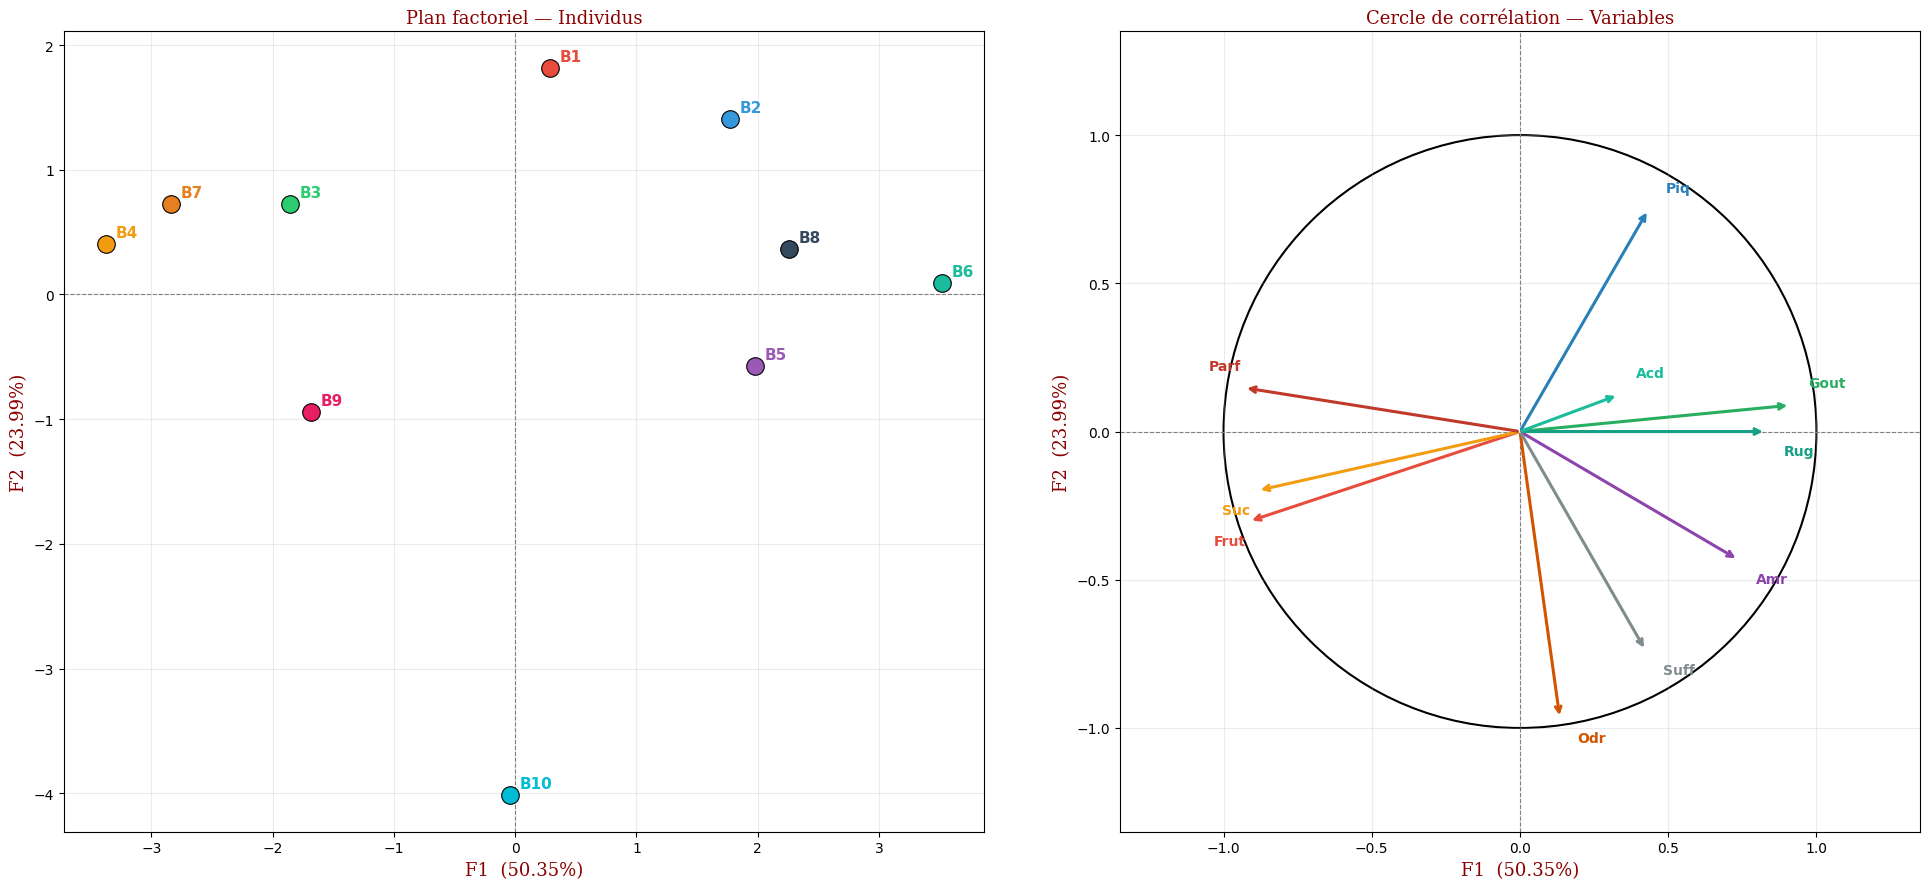

In [59]:
fig, axs = plt.subplots(1, 2, figsize=(20, 9))

# --- Plan des individus ---
ax1 = axs[0]
ax1.axhline(0, color='gray', linestyle='--', linewidth=0.8)
ax1.axvline(0, color='gray', linestyle='--', linewidth=0.8)
for i in range(m):
    ax1.scatter(C[i,0], C[i,1], color=colors_b[i], s=160, zorder=5,
                edgecolors='black', linewidth=0.8)
    ax1.annotate(boissons[i], (C[i,0], C[i,1]),
                 textcoords='offset points', xytext=(7,5),
                 fontsize=11, fontweight='bold', color=colors_b[i])
ax1.set_xlabel(f"F1  ({taux_pct[0]:.2f}%)", fontdict=font)
ax1.set_ylabel(f"F2  ({taux_pct[1]:.2f}%)", fontdict=font)
ax1.set_title("Plan factoriel — Individus", fontdict=font)
ax1.grid(True, alpha=0.25)

# --- Cercle de corrélation ---
ax2 = axs[1]
cercle = plt.Circle((0,0), 1, color='black', fill=False, linewidth=1.5)
ax2.add_patch(cercle)
ax2.axhline(0, color='gray', linestyle='--', linewidth=0.8)
ax2.axvline(0, color='gray', linestyle='--', linewidth=0.8)
for j, var in enumerate(vars_names):
    x, y = coords_vars[j,0], coords_vars[j,1]
    ax2.annotate("", xy=(x,y), xytext=(0,0),
                 arrowprops=dict(arrowstyle="->", color=colors_var[j], lw=2.2))
    ox = 0.06 if x >= 0 else -0.12
    oy = 0.06 if y >= 0 else -0.08
    ax2.text(x+ox, y+oy, var, fontsize=10, fontweight='bold', color=colors_var[j])
ax2.set_xlim(-1.35,1.35); ax2.set_ylim(-1.35,1.35)
ax2.set_xlabel(f"F1  ({taux_pct[0]:.2f}%)", fontdict=font)
ax2.set_ylabel(f"F2  ({taux_pct[1]:.2f}%)", fontdict=font)
ax2.set_title("Cercle de corrélation — Variables", fontdict=font)
ax2.set_aspect('equal')
ax2.grid(True, alpha=0.25)

plt.tight_layout()
plt.show()

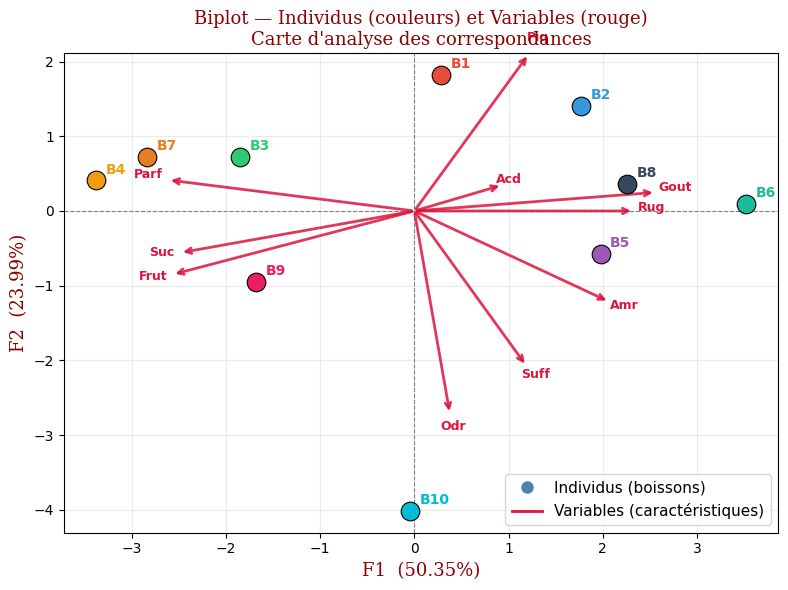

In [60]:
# --- Biplot (tout en un) ---
fig, ax = plt.subplots(figsize=(8, 6))
ax.axhline(0, color='gray', linestyle='--', linewidth=0.8)
ax.axvline(0, color='gray', linestyle='--', linewidth=0.8)

# Individus (points)
for i in range(m):
    ax.scatter(C[i,0], C[i,1], color=colors_b[i], s=180, zorder=5,
               edgecolors='black', linewidth=0.8)
    ax.annotate(boissons[i], (C[i,0], C[i,1]),
                textcoords='offset points', xytext=(7,5),
                fontsize=10, fontweight='bold', color=colors_b[i])

# Variables (flèches), mise à l'échelle pour visibilité
scale = max(np.abs(C[:,0]).max(), np.abs(C[:,1]).max()) * 0.7
for j, var in enumerate(vars_names):
    x = coords_vars[j,0] * scale
    y = coords_vars[j,1] * scale
    ax.annotate("", xy=(x,y), xytext=(0,0),
                arrowprops=dict(arrowstyle="->", color='crimson', lw=2.0, alpha=0.85))
    ax.text(x*1.08, y*1.08, var, fontsize=9, fontweight='bold',
            color='crimson', ha='center')

from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0],[0], marker='o', color='w', markerfacecolor='steelblue',
           markersize=10, label='Individus (boissons)'),
    Line2D([0],[0], color='crimson', linewidth=2, label='Variables (caractéristiques)')
]
ax.legend(handles=legend_elements, fontsize=11, loc='lower right')
ax.set_xlabel(f"F1  ({taux_pct[0]:.2f}%)", fontdict=font)
ax.set_ylabel(f"F2  ({taux_pct[1]:.2f}%)", fontdict=font)
ax.set_title("Biplot — Individus (couleurs) et Variables (rouge)\n"
             "Carte d'analyse des correspondances", fontdict=font)
ax.grid(True, alpha=0.25)
plt.tight_layout()
plt.show()

## Synthèse et Interprétation globale

### Caractérisation des boissons

| Boisson | Profil sensoriel dominant | Caractéristiques |
|---------|--------------------------|------------------|
| **B4** | Très fruité, sucré, parfumé | F1 très négatif → boisson **premium fruitée** |
| **B7** | Fruité, sucré, peu amer | Proche de B4 → **doux et parfumé** |
| **B9** | Fruité, sucré, parfumé | Similaire à B4/B7 → **groupe des boissons fruitées** |
| **B3** | Sucré, parfumé mais goût modéré | Intermédiaire dans le groupe fruité |
| **B6** | Très amer, goût fort, peu fruité | F1 très positif → boisson **intense et âpre** |
| **B5** | Amer, piquant, peu fruité | Similaire à B6 → **groupe des boissons fortes** |
| **B8** | Amer, peu de saveur douce | Proche de B6/B5 → **profil brut, peu aromatique** |
| **B2** | Profil intermédiaire | Équilibre entre douceur et amertume |
| **B1** | Profil équilibré | Ni trop fruité ni trop amer → **boisson moyenne** |
| **B10** | **Très odorante** et suffocante | Atypique sur F2 → **dimension olfactive unique** |

### Points communs entre boissons

- **B3, B4, B7, B9** → groupe **fruité-sucré-parfumé** : boissons agréables, douces, aromatiques
- **B5, B6, B8** → groupe **amer-rugosité-goût** : boissons intenses, caractère fort
- **B10** → cas unique : Odr=6.10 (très élevé) → boisson à identité olfactive très marquée
- **B1, B2** → groupe central équilibré : notes modérées sur toutes les dimensions

### Conclusion

L'ACP normée a permis de réduire 10 caractéristiques en **3 axes** expliquant **85.88%** de l'information :
- **F1** : distingue les boissons **fruitées/douces** des boissons **amères/rugueuses**
- **F2** : isole les boissons à forte **odeur/suffocant** (B10) des boissons **piquantes**
- **F3** : discrimine selon l'**acidité** (B4, B7)

Cette analyse pourrait guider les décisions de formulation et de positionnement des boissons sur le marché.